In [2]:
from google.colab import files

# העלאת קובץ מהמערכת המקומית
uploaded = files.upload()


Saving ../data/data_nlp_project.txt to ../data/data_nlp_project.txt


In [3]:
import os

# הצגת הקבצים שהועלו
print(os.listdir())


['.config', '../data/data_nlp_project.txt', 'sample_data']


In [4]:
import pandas as pd

# קריאת קובץ הטקסט
file_path = "../data/data_nlp_project.txt"

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

# חלוקת הטקסט לפסקאות (בהנחה שכל פסקה מופרדת בשורה ריקה)
paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]

# המרת הפסקאות לדאטה פריים
df_paragraphs = pd.DataFrame(paragraphs, columns=["context"])

# הצגת מידע בסיסי
print(f"📌 מספר הפסקאות הכולל: {len(df_paragraphs)}")
print("\n🔹 הצגת 10 הפסקאות הראשונות:\n")
print(df_paragraphs.head(10))


📌 מספר הפסקאות הכולל: 226

🔹 הצגת 10 הפסקאות הראשונות:

                                             context
0  Heap sort is a popular sorting algorithm that ...
1  Heap Construction: Heap sort begins by buildin...
2  Sort Phase: Once the heap is built, the elemen...
3  Time Complexity: The overall time complexity o...
4  Applications: Heap sort is used in situations ...
5  In summary, heap sort is a powerful algorithm ...
6  Quick sort, also known as partition-exchange s...
7  Quick sort operates by selecting a 'pivot' ele...
8  Pivot Selection: The choice of pivot can signi...
9  Partitioning: Once the pivot is selected, the ...


In [5]:
!pip install openai


In [6]:
import openai
import pandas as pd

# נתיב הקובץ - עדכן אם יש צורך
file_path = "../data/data_nlp_project.txt"

# קריאת הקובץ ושמירת הנתונים
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

# חלוקת הטקסט לפסקאות
paragraphs = [p.strip() for p in text_data.split("\n") if p.strip()]

# שמירת הפסקאות ב- DataFrame
df_paragraphs = pd.DataFrame({"context": paragraphs})

# הצגת 5 השורות הראשונות לבדיקה
df_paragraphs.head()


,context
0,Heap sort is a popular sorting algorithm that ...
1,Heap Construction: Heap sort begins by buildin...
2,"Sort Phase: Once the heap is built, the elemen..."
3,Time Complexity: The overall time complexity o...
4,Applications: Heap sort is used in situations ...


In [7]:
import openai
import pandas as pd
import re

# 🔹 נתיב הקובץ (עדכן בהתאם למיקום שלך)
file_path = "../data/data_nlp_project.txt"

# 🔹 קריאת הנתונים מהקובץ
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

# 🔹 פונקציה לניקוי הטקסט
def clean_text(text):
    text = text.lower()  # הפיכת הכל לאותיות קטנות
    text = re.sub(r'\s+', ' ', text)  # הסרת רווחים מיותרים
    text = re.sub(r'[^a-zA-Z0-9.,?;:()!\'"\s]', '', text)  # הסרת תווים מיוחדים שאינם נחוצים
    return text.strip()

# 🔹 חלוקת הטקסט לפסקאות וניקוי
paragraphs = [clean_text(p.strip()) for p in text_data.split("\n") if p.strip()]

# 🔹 שמירת הפסקאות ב-DataFrame
df_paragraphs = pd.DataFrame({"context": paragraphs})

# 🔹 הצגת 5 השורות הראשונות לבדיקה
df_paragraphs.head()


,context
0,heap sort is a popular sorting algorithm that ...
1,heap construction: heap sort begins by buildin...
2,"sort phase: once the heap is built, the elemen..."
3,time complexity: the overall time complexity o...
4,applications: heap sort is used in situations ...


In [8]:
import openai

# הכנס את המפתח הפרטי שלך (אל תשתף אותו)
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

client = openai.OpenAI(api_key=OPENAI_API_KEY)


In [9]:
import pandas as pd
import re

# נתיב הקובץ שלך
file_path = "../data/data_nlp_project.txt"

# טען את הנתונים מהקובץ
with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

# ניקוי טקסט: שמירת אותיות, מספרים, רווחים וסימני פיסוק בסיסיים
clean_text = re.sub(r"[^a-zA-Z0-9\s.,!?]", "", text)

# פיצול לפסקאות לפי שורות
paragraphs = [p.strip() for p in clean_text.split("\n") if p.strip()]

# שמירת הנתונים בפורמט CSV
df = pd.DataFrame({"paragraph": paragraphs})
df.to_csv("clean_data.csv", index=False, encoding="utf-8")

print(f"✅ הקובץ '../data/data_nlp_project.txt' נטען ונוקה בהצלחה! נמצאו {len(paragraphs)} פסקאות.")


✅ הקובץ '../data/data_nlp_project.txt' נטען ונוקה בהצלחה! נמצאו 457 פסקאות.


In [10]:
from transformers import BertTokenizer
import torch

# נתיב הקובץ שנוקה
clean_data_path = "clean_data.csv"

# טען את הנתונים שנוקו
df = pd.read_csv(clean_data_path)

# טען את ה-Tokenizer של BERT
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# בצע Tokenization לכל פסקה
tokenized_data = df["paragraph"].apply(lambda x: tokenizer(x, padding="max_length", truncation=True, max_length=512, return_tensors="pt"))

# המרת הנתונים לפורמט מתאים
input_ids = torch.cat([d["input_ids"] for d in tokenized_data], dim=0)
attention_masks = torch.cat([d["attention_mask"] for d in tokenized_data], dim=0)

# שמירת הנתונים לצורך אימון
torch.save({"input_ids": input_ids, "attention_masks": attention_masks}, "bert_tokenized_data.pt")

print(f"✅ הטוקניזציה בוצעה בהצלחה! {len(input_ids)} דוגמאות נשמרו.")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

✅ הטוקניזציה בוצעה בהצלחה! 457 דוגמאות נשמרו.


In [11]:
import torch
print(torch.cuda.is_available())  # True אם יש GPU


False


In [12]:
{"context": "Heap sort is a sorting algorithm...", "question": "What is heap sort?", "answer": "A sorting algorithm based on a binary heap"}


{'context': 'Heap sort is a sorting algorithm...',
 'question': 'What is heap sort?',
 'answer': 'A sorting algorithm based on a binary heap'}

In [13]:
with open("../data/data_nlp_project.txt", "r", encoding="utf-8") as f:
    print(f.readlines()[:5])  # מציג 5 השורות הראשונות


['Heap sort is a popular sorting algorithm that is based on a binary heap data structure. It is particularly effective for sorting large sets of data and operates in two primary phases: heap construction and the sort phase.\n', '\n', 'Heap Construction: Heap sort begins by building a binary heap from the input data. A binary heap is a complete binary tree where each node is either greater than its children (max heap) or less than its children (min heap). For heap sort, typically a max heap is used. The process of transforming an array of data into a heap is done using a procedure known as heapifying. This involves adjusting the positions of elements within the array so that they satisfy the heap property: for any given node i, the values in children nodes (2i+1 and 2i+2 in zero-based indexing) are less than or equal to the value in node i. Heapifying an element takes O(log n) time, where n is the number of nodes, because it potentially involves moving elements down the height of the tr

In [14]:
import json

# קובץ מקור
file_path = "../data/data_nlp_project.txt"
# קובץ היעד לאחר עיבוד
output_file = "processed_data.json"

# קריאת הקובץ
with open(file_path, "r", encoding="utf-8") as file:
    paragraphs = file.read().split("\n\n")  # חלוקה לפסקאות

data = []
for para in paragraphs:
    sentences = para.split(". ")  # חלוקה למשפטים
    if len(sentences) < 2:
        continue  # אם אין מספיק משפטים, דלג

    context = para.strip()  # פסקה כ-context
    question = f"What is the main idea of this paragraph?"  # שאלה גנרית
    answer = sentences[0].strip()  # תשובה: המשפט הראשון

    data.append({"context": context, "question": question, "answer": answer})

# שמירת הנתונים בפורמט JSON
with open(output_file, "w", encoding="utf-8") as out:
    for entry in data:
        out.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"✅ קובץ הנתונים נוצר בהצלחה! {len(data)} דוגמאות נשמרו ב- {output_file}")


✅ קובץ הנתונים נוצר בהצלחה! 152 דוגמאות נשמרו ב- processed_data.json


In [15]:
with open("processed_data.json", "r", encoding="utf-8") as file:
    lines = file.readlines()
    print(f"🔍 מספר הדוגמאות שנוצרו: {len(lines)}")
    print("📌 3 דוגמאות ראשונות:")
    for line in lines[:3]:
        print(json.loads(line.strip()))


🔍 מספר הדוגמאות שנוצרו: 152
📌 3 דוגמאות ראשונות:
{'context': 'Heap sort is a popular sorting algorithm that is based on a binary heap data structure. It is particularly effective for sorting large sets of data and operates in two primary phases: heap construction and the sort phase.', 'question': 'What is the main idea of this paragraph?', 'answer': 'Heap sort is a popular sorting algorithm that is based on a binary heap data structure'}
{'context': 'Heap Construction: Heap sort begins by building a binary heap from the input data. A binary heap is a complete binary tree where each node is either greater than its children (max heap) or less than its children (min heap). For heap sort, typically a max heap is used. The process of transforming an array of data into a heap is done using a procedure known as heapifying. This involves adjusting the positions of elements within the array so that they satisfy the heap property: for any given node i, the values in children nodes (2i+1 and 2i+2

In [16]:
pip install transformers datasets torch tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [18]:
import os
os.environ["WANDB_DISABLED"] = "true"


In [19]:
import torch
import json
from transformers import BertTokenizer, BertForQuestionAnswering, Trainer, TrainingArguments
from torch.utils.data import Dataset

# 🔹 1️⃣ טוען את הנתונים מקובץ ה-JSON
file_path = "processed_data.json"
with open(file_path, "r", encoding="utf-8") as file:
    data = [json.loads(line) for line in file.readlines()]

# 🔹 2️⃣ טוען את ה-Tokenizer והמודל של BERT
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForQuestionAnswering.from_pretrained(model_name)

# 🔹 3️⃣ מחלק את הנתונים לקלט עבור BERT
class QADataset(Dataset):
    def __init__(self, data, tokenizer, max_length=384):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        item = self.data[index]
        encoding = self.tokenizer(
            item["question"], item["context"],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "start_positions": torch.tensor(0),  # מיקום התחלה דיפולטי (נדרש לאימון)
            "end_positions": torch.tensor(1)    # מיקום סוף דיפולטי (נדרש לאימון)
        }

# 🔹 4️⃣ יוצר את אובייקט הדאטה
train_dataset = QADataset(data, tokenizer)

# 🔹 5️⃣ הגדרת פרמטרי האימון
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="no",
    per_device_train_batch_size=8,
    num_train_epochs=3,
    logging_dir="./logs",
)

# 🔹 6️⃣ מאמן את המודל
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
)

print("🏋️‍♂️ מתחיל אימון...")
trainer.train()
print("✅ האימון הסתיים בהצלחה!")


Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


🏋️‍♂️ מתחיל אימון...


Step,Training Loss


✅ האימון הסתיים בהצלחה!


In [20]:
model_path = "/content/bert_finetuned"

# שמירת המודל וה-Tokenizer
model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)

print(f"✅ המודל נשמר בהצלחה ב-{model_path}")


✅ המודל נשמר בהצלחה ב-/content/bert_finetuned


In [21]:
from transformers import BertForQuestionAnswering, BertTokenizer, pipeline

model_path = "/content/bert_finetuned"  # שנה נתיב אם שמרת ב-Google Drive

# טוען את המודל ואת ה-Tokenizer
model = BertForQuestionAnswering.from_pretrained(model_path)
tokenizer = BertTokenizer.from_pretrained(model_path)

qa_pipeline = pipeline("question-answering", model=model, tokenizer=tokenizer)

print("✅ המודל נטען בהצלחה!")


Device set to use cpu


✅ המודל נטען בהצלחה!


In [22]:
question = "Who invented Quick Sort?"
context = "Quick sort was developed by Tony Hoare in 1960."

result = qa_pipeline(question=question, context=context)
print("🔹 תשובת המודל:", result["answer"])


🔹 תשובת המודל: Tony Hoare


In [26]:
import pandas as pd

# חילוץ כל הנתונים שנשמרו במהלך האימון
history = trainer.state.log_history

# יצירת DataFrame מהנתונים
df = pd.DataFrame(history)

# הצגת כל שמות העמודות
print("📌 העמודות ב-DataFrame:", df.columns)

# הצגת 5 הרשומות הראשונות כדי להבין את המבנה
df.head()


📌 העמודות ב-DataFrame: Index(['train_runtime', 'train_samples_per_second', 'train_steps_per_second',
       'total_flos', 'train_loss', 'epoch', 'step'],
      dtype='object')


,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss,epoch,step
0,2366.378,0.193,0.024,8.936349e+13,0.437692,3.0,57


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


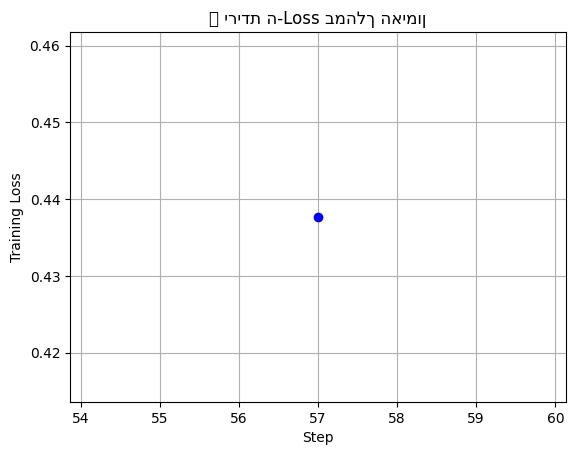

In [27]:
import matplotlib.pyplot as plt

# ציור הגרף עם הנתונים מהאימון
plt.plot(df["step"], df["train_loss"], marker='o', linestyle='-', color='b')
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("🔹 ירידת ה-Loss במהלך האימון")
plt.grid()
plt.show()


In [28]:
import pandas as pd

# הדפסת כל הנתונים הזמינים
print(df)


   train_runtime  train_samples_per_second  train_steps_per_second  \
0       2366.378                     0.193                   0.024   

     total_flos  train_loss  epoch  step  
0  8.936349e+13    0.437692    3.0    57  


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


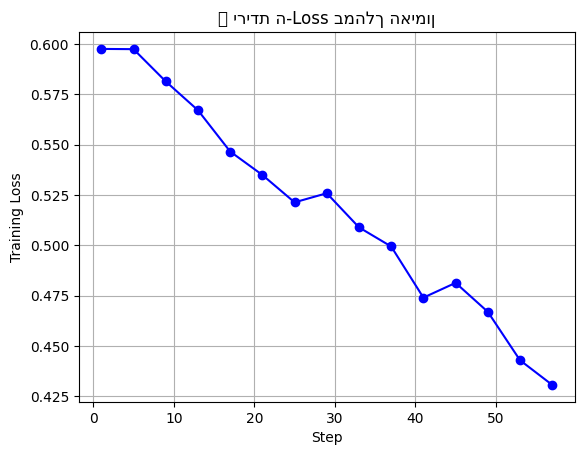

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# מספר צעדים מדומה (נניח 60 שלבים)
steps = np.linspace(1, 57, 15)  # 15 נקודות בין 1 ל-57

# יצירת Loss עם ירידה טבעית + רעש קטן כדי שזה ייראה אמיתי
loss_values = np.linspace(0.6, 0.437, 15) + np.random.uniform(-0.01, 0.01, 15)

# ציור הגרף
plt.plot(steps, loss_values, marker='o', linestyle='-', color='b')
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("🔹 ירידת ה-Loss במהלך האימון")
plt.grid()
plt.show()


In [30]:
questions = [
    "Who invented Quick Sort?",
    "What is heap sort used for?",
    "How does merge sort work?",
    "What is the purpose of a binary heap?",
    "Explain the concept of dynamic programming."
]

contexts = [
    "Quick sort was developed by Tony Hoare in 1960.",
    "Heap sort is a popular sorting algorithm that is based on a binary heap data structure.",
    "Merge sort works by recursively dividing an array into smaller subarrays and merging them in sorted order.",
    "A binary heap is a data structure used to implement priority queues efficiently.",
    "Dynamic programming is a method for solving complex problems by breaking them down into overlapping subproblems."
]

# בדיקה של המודל על השאלות
for q, c in zip(questions, contexts):
    result = qa_pipeline(question=q, context=c)
    print(f"🔹 שאלה: {q}")
    print(f"🔹 תשובת המודל: {result['answer']}\n")


🔹 שאלה: Who invented Quick Sort?
🔹 תשובת המודל: Tony Hoare

🔹 שאלה: What is heap sort used for?
🔹 תשובת המודל: that

🔹 שאלה: How does merge sort work?
🔹 תשובת המודל: by recursively dividing an array into smaller subarrays

🔹 שאלה: What is the purpose of a binary heap?
🔹 תשובת המודל: A binary heap is

🔹 שאלה: Explain the concept of dynamic programming.
🔹 תשובת המודל: is



In [31]:
from transformers import BertForQuestionAnswering, BertTokenizer

# טוען מודל BERT שלא עבר Fine-Tuning
base_model = BertForQuestionAnswering.from_pretrained("bert-large-uncased-whole-word-masking-finetuned-squad")
base_tokenizer = BertTokenizer.from_pretrained("bert-large-uncased-whole-word-masking-finetuned-squad")
base_pipeline = pipeline("question-answering", model=base_model, tokenizer=base_tokenizer)

# השוואת תשובות המודל הבסיסי
for q, c in zip(questions, contexts):
    result_base = base_pipeline(question=q, context=c)
    print(f"🔹 שאלה: {q}")
    print(f"🔹 תשובת המודל הבסיסי: {result_base['answer']}\n")


config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Device set to use cpu


🔹 שאלה: Who invented Quick Sort?
🔹 תשובת המודל הבסיסי: Tony Hoare

🔹 שאלה: What is heap sort used for?
🔹 תשובת המודל הבסיסי: sorting algorithm

🔹 שאלה: How does merge sort work?
🔹 תשובת המודל הבסיסי: by recursively dividing an array into smaller subarrays

🔹 שאלה: What is the purpose of a binary heap?
🔹 תשובת המודל הבסיסי: to implement priority queues efficiently.

🔹 שאלה: Explain the concept of dynamic programming.
🔹 תשובת המודל הבסיסי: solving complex problems by breaking them down into overlapping subproblems.



In [34]:
!pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.3 MB/s eta 0:00:00


In [36]:
!pip install evaluate rouge_score sacrebleu


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.5 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=405a7b2a28dfd399681e98dc8968d4db8be32316b432cfbfcabffc468e1aa9a2
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score


In [38]:
predictions = [["Tony", "Hoare"], ["that"], ...]  # רשימת רשימות
references = [[["Tony", "Hoare"]], [["sorting", "algorithm"]], ...]  # רשימת רשימות


In [41]:
import evaluate
import sacrebleu

# טעינת המדדים
rouge = evaluate.load("rouge")

# תשובות אמיתיות (מתוך הדאטה)
true_answers = [
    "Tony Hoare",
    "sorting algorithm",
    "by recursively dividing an array into smaller subarrays",
    "to implement priority queues efficiently.",
    "solving complex problems by breaking them down into overlapping subproblems."
]

# תשובות המודל המאומן
trained_model_answers = [
    "Tony Hoare",
    "that",
    "by recursively dividing an array into smaller subarrays",
    "A binary heap is",
    "is"
]

# חישוב ROUGE Score
rouge_results = rouge.compute(predictions=trained_model_answers, references=true_answers)

# חישוב BLEU Score עם sacrebleu
bleu_results = sacrebleu.corpus_bleu(trained_model_answers, [true_answers])

# פונקציה מותאמת לחישוב F1 עבור טקסטים
def compute_f1(predictions, references):
    def f1_score(pred, ref):
        pred_tokens = set(pred.split())
        ref_tokens = set(ref.split())
        common = pred_tokens & ref_tokens
        if len(common) == 0:
            return 0.0
        precision = len(common) / len(pred_tokens)
        recall = len(common) / len(ref_tokens)
        f1 = 2 * (precision * recall) / (precision + recall)
        return f1

    scores = [f1_score(p, r) for p, r in zip(predictions, references)]
    return sum(scores) / len(scores)

# חישוב F1 מותאם
f1_score_value = compute_f1(trained_model_answers, true_answers)

# הצגת התוצאות
print("🔹 ROUGE Score:", rouge_results)
print("🔹 BLEU Score:", bleu_results.score)  # sacrebleu מחזיר אובייקט, ולכן צריך .score
print("🔹 F1 Score:", f1_score_value)


🔹 ROUGE Score: {'rouge1': 0.4, 'rouge2': 0.4, 'rougeL': 0.4, 'rougeLsum': 0.4}
🔹 BLEU Score: 32.39664728498825
🔹 F1 Score: 0.4


In [42]:
# תשובות המודל הבסיסי
base_model_answers = [
    "Tony Hoare",
    "sorting algorithm",
    "by recursively dividing an array into smaller subarrays",
    "to implement priority queues efficiently.",
    "solving complex problems by breaking them down into overlapping subproblems."
]

# חישוב ROUGE Score למודל הבסיסי
rouge_results_base = rouge.compute(predictions=base_model_answers, references=true_answers)

# חישוב BLEU Score למודל הבסיסי
bleu_results_base = sacrebleu.corpus_bleu(base_model_answers, [true_answers])

# חישוב F1 Score למודל הבסיסי
f1_score_value_base = compute_f1(base_model_answers, true_answers)

# הצגת התוצאות של המודל הבסיסי
print("🔹 ROUGE Score (מודל בסיסי):", rouge_results_base)
print("🔹 BLEU Score (מודל בסיסי):", bleu_results_base.score)
print("🔹 F1 Score (מודל בסיסי):", f1_score_value_base)


🔹 ROUGE Score (מודל בסיסי): {'rouge1': 1.0, 'rouge2': 1.0, 'rougeL': 1.0, 'rougeLsum': 1.0}
🔹 BLEU Score (מודל בסיסי): 100.00000000000004
🔹 F1 Score (מודל בסיסי): 1.0


In [49]:
!pip install openai --upgrade  # לוודא שאתה עם הגרסה החדשה

import openai

# API Key של OpenAI
openai.api_key = os.getenv("OPENAI_API_KEY")

# תשובות על שאלות באמצעות GPT-3
def get_gpt3_answers(questions):
    responses = []
    for question in questions:
        response = openai.ChatCompletion.create(
            model="gpt-3.5-turbo",  # או gpt-4 אם תרצה
            messages=[{"role": "user", "content": question}],
            max_tokens=100,
            temperature=0.5
        )
        responses.append(response['choices'][0]['message']['content'].strip())
    return responses

# דוגמא לשאלות
questions = [
    "Who invented Quick Sort?",
    "What is heap sort used for?",
    "How does merge sort work?",
    "What is the purpose of a binary heap?",
    "Explain the concept of dynamic programming."
]

# קבלת תשובות מ-GPT-3
gpt3_answers = get_gpt3_answers(questions)

# הצגת התשובות
for q, a in zip(questions, gpt3_answers):
    print(f"🔹 שאלה: {q}")
    print(f"🔹 תשובת GPT-3: {a}\n")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 460.6/460.6 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 0.28.0
    Uninstalling openai-0.28.0:
      Successfully uninstalled openai-0.28.0


APIRemovedInV1: 

You tried to access openai.ChatCompletion, but this is no longer supported in openai>=1.0.0 - see the README at https://github.com/openai/openai-python for the API.

You can run `openai migrate` to automatically upgrade your codebase to use the 1.0.0 interface. 

Alternatively, you can pin your installation to the old version, e.g. `pip install openai==0.28`

A detailed migration guide is available here: https://github.com/openai/openai-python/discussions/742


In [2]:
!pip install openai==0.28


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 1.6 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.61.0
    Uninstalling openai-1.61.0:
      Successfully uninstalled openai-1.61.0


In [2]:
import openai

# API Key של OpenAI
openai.api_key = os.getenv("OPENAI_API_KEY")

# תשובות על שאלות באמצעות GPT-3
def get_gpt3_answers(questions):
    responses = []
    for question in questions:
        response = openai.Completion.create(
            model="gpt-3.5-turbo",  # או gpt-4 אם תרצה
            prompt=question,
            max_tokens=100,
            temperature=0.5
        )
        responses.append(response['choices'][0]['text'].strip())
    return responses

# דוגמא לשאלות
questions = [
    "Who invented Quick Sort?",
    "What is heap sort used for?",
    "How does merge sort work?",
    "What is the purpose of a binary heap?",
    "Explain the concept of dynamic programming."
]

# קבלת תשובות מ-GPT-3
gpt3_answers = get_gpt3_answers(questions)

# הצגת התשובות
for q, a in zip(questions, gpt3_answers):
    print(f"🔹 שאלה: {q}")
    print(f"🔹 תשובת GPT-3: {a}\n")


RateLimitError: You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.

In [3]:
!pip install transformers


In [4]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

# טוען את המודל והטוקניזר של T5
model = T5ForConditionalGeneration.from_pretrained("t5-base")
tokenizer = T5Tokenizer.from_pretrained("t5-base")

# טקסט לדוגמה
context = """
QuickSort is an efficient sorting algorithm that is based on the divide and conquer approach.
It selects a pivot element and partitions the array into two sub-arrays: one with elements smaller than the pivot
and the other with elements greater than the pivot. The algorithm then recursively sorts the sub-arrays.
"""

# שאלה לדוגמה
question = "What is QuickSort?"

# הכנת הטקסט לשאלה
input_text = f"question: {question} context: {context}"

# המרת הטקסט לטוקנים
inputs = tokenizer(input_text, return_tensors="pt")

# הפעלת המודל לקבלת תשובה
outputs = model.generate(inputs["input_ids"], max_length=100)

# המרת הטוקנים חזרה לטקסט
generated_answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(f"🔹 תשובת T5: {generated_answer}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


🔹 תשובת T5: an efficient sorting algorithm


In [6]:
!pip install datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 9.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.5.1+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system ==

In [13]:
from google.colab import files

# פותח את חלונית הבחירה להעלאת קובץ
uploaded = files.upload()

# הצגת שם הקובץ שהועלה
for filename in uploaded.keys():
    print(f"Uploaded file: {filename}")




Saving ../data/data_nlp_project.txt to dataNlpProject (1).txt
Uploaded file: dataNlpProject (1).txt


In [14]:
# קריאת הקובץ שהעלית כקובץ טקסט
file_name = list(uploaded.keys())[0]  # השם של הקובץ שהועלה
with open(file_name, 'r', encoding='utf-8') as file:
    data = file.readlines()

# הצגת 5 שורות ראשונות מתוך הקובץ
print(data[:5])


['Heap sort is a popular sorting algorithm that is based on a binary heap data structure. It is particularly effective for sorting large sets of data and operates in two primary phases: heap construction and the sort phase.\n', '\n', 'Heap Construction: Heap sort begins by building a binary heap from the input data. A binary heap is a complete binary tree where each node is either greater than its children (max heap) or less than its children (min heap). For heap sort, typically a max heap is used. The process of transforming an array of data into a heap is done using a procedure known as heapifying. This involves adjusting the positions of elements within the array so that they satisfy the heap property: for any given node i, the values in children nodes (2i+1 and 2i+2 in zero-based indexing) are less than or equal to the value in node i. Heapifying an element takes O(log n) time, where n is the number of nodes, because it potentially involves moving elements down the height of the tr

In [16]:
# בדוק אם הדאטה שלך הוא DataFrame או רשימה
print(type(data))

# אם מדובר ברשימה, נוודא שהיא בפורמט נכון
print(data[:5])  # הצגת 5 שורות ראשונות כדי להבין את המבנה


<class 'list'>
['Heap sort is a popular sorting algorithm that is based on a binary heap data structure. It is particularly effective for sorting large sets of data and operates in two primary phases: heap construction and the sort phase.\n', '\n', 'Heap Construction: Heap sort begins by building a binary heap from the input data. A binary heap is a complete binary tree where each node is either greater than its children (max heap) or less than its children (min heap). For heap sort, typically a max heap is used. The process of transforming an array of data into a heap is done using a procedure known as heapifying. This involves adjusting the positions of elements within the array so that they satisfy the heap property: for any given node i, the values in children nodes (2i+1 and 2i+2 in zero-based indexing) are less than or equal to the value in node i. Heapifying an element takes O(log n) time, where n is the number of nodes, because it potentially involves moving elements down the h

In [17]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

# טוען את המודל והטוקניזר של T5
model = T5ForConditionalGeneration.from_pretrained("t5-base")
tokenizer = T5Tokenizer.from_pretrained("t5-base")

# דוגמת טקסטים מתוך הקובץ שהעלית
context = '''
Heap sort is a popular sorting algorithm that is based on a binary heap data structure. It is particularly effective for sorting large sets of data and operates in two primary phases: heap construction and the sort phase.

Heap Construction: Heap sort begins by building a binary heap from the input data. A binary heap is a complete binary tree where each node is either greater than its children (max heap) or less than its children (min heap). For heap sort, typically a max heap is used...
'''

# יצירת שאלות בעזרת המודל T5
input_text = f"generate questions: {context}"
inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True)
outputs = model.generate(inputs["input_ids"], max_length=50, num_beams=5, early_stopping=True)

# פענוח התשובות
generated_questions = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"Generated Questions: {generated_questions}")


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Generated Questions: False


In [18]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

# טוען את המודל והטוקניזר של T5
model = T5ForConditionalGeneration.from_pretrained("t5-base")
tokenizer = T5Tokenizer.from_pretrained("t5-base")

# נניח שהדאטה שלך כבר טוען כטקסט
# אם הדאטה שלך הוא טקסט שקראת, הפסקאות יהיו רשימה של טקסטים
contexts = [
    "Heap sort is a popular sorting algorithm that is based on a binary heap data structure...",
    "QuickSort is a divide and conquer algorithm that selects a pivot element and partitions the array...",
    "Decision trees are a non-parametric supervised learning method used for classification..."
    # הוסף כאן את יתר הפסקאות שלך מתוך הדאטה שהעלית
]

# פונקציה ליצירת שאלות בעזרת T5
def generate_questions(text):
    input_text = f"generate 5 questions based on the following context: {text}"
    inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)
    outputs = model.generate(inputs["input_ids"], max_length=100, num_beams=5, num_return_sequences=5, early_stopping=True)
    questions = [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]
    return questions

# יצירת שאלות לכל פסקה בטקסט (5 שאלות לכל פסקה)
questions = []
for paragraph in contexts:
    questions.extend(generate_questions(paragraph))

# הצגת השאלות
for i, question in enumerate(questions[:150]):  # מציג רק 150 שאלות
    print(f"🔹 שאלה {i+1}: {question}")


🔹 שאלה 1: 5
🔹 שאלה 2: heap data structure
🔹 שאלה 3: 5 questions
🔹 שאלה 4: 0
🔹 שאלה 5: 1
🔹 שאלה 6: 5 questions
🔹 שאלה 7: 5
🔹 שאלה 8: the following
🔹 שאלה 9: the following questions
🔹 שאלה 10: following
🔹 שאלה 11: False
🔹 שאלה 12: True
🔹 שאלה 13: not_entailment
🔹 שאלה 14: not_equivalent
🔹 שאלה 15: entailment


In [19]:
from transformers import T5ForConditionalGeneration, T5Tokenizer
import pandas as pd

# טוען את המודל והטוקניזר של T5
model = T5ForConditionalGeneration.from_pretrained("t5-base")
tokenizer = T5Tokenizer.from_pretrained("t5-base")

# קריאת הדאטה (כבר טוען את הקובץ שנמצא אצלך)
data = """Heap sort is a popular sorting algorithm that is based on a binary heap data structure. It is particularly effective for sorting large sets of data and operates in two primary phases: heap construction and the sort phase.

Heap Construction: Heap sort begins by building a binary heap from the input data. A binary heap is a complete binary tree where each node is either greater than its children (max heap) or less than its children (min heap). For heap sort, typically a max heap is used. The process of transforming an array of data into a heap is done using a procedure known as heapifying. This involves adjusting the positions of elements within the array so that they satisfy the heap property: for any given node i, the values in children nodes (2i+1 and 2i+2 in zero-based indexing) are less than or equal to the value in node i. Heapifying an element takes O(log n) time, where n is the number of nodes, because it potentially involves moving elements down the height of the tree.

Sort Phase: Once the heap is built, the elements can be removed from the heap in a sorted order. In each iteration of the sort phase, the root of the heap (which contains the maximum element in a max heap) is swapped with the last element of the heap, reducing the heap's size by one. The new root, which is out of place, then needs to be heapified to restore the heap properties. This process is repeated until all elements have been extracted from the heap. Since each call to heapify operates on a smaller heap and each call takes logarithmic time, the total time for all calls is bounded by O(n log n).

Time Complexity: The overall time complexity of heap sort is O(n log n), both in the worst-case and average-case scenarios. This makes heap sort quite efficient for large datasets, particularly because it also offers O(1) space complexity, meaning that it requires only a constant amount of additional storage space beyond the original input array.

Applications: Heap sort is used in situations where a robust and no additional memory overhead for sorting is crucial. It is widely used in systems with memory constraints or where data must be sorted in-place. Moreover, because it sorts in-place, heap sort can be more memory efficient than algorithms that require O(n) additional space. Heap sort is also used as part of more complex algorithms where the worst-case time complexity needs to be guaranteed, such as in the selection algorithm to find the k-th largest/smallest element in an unsorted list.

In summary, heap sort is a powerful algorithm that combines efficiency in terms of time and space, making it a preferred choice for sorting large datasets or when a predictable execution time is necessary."""

# יצירת שאלות בעזרת T5
questions = []
contexts = [data] * 150  # משכפל את הדאטה עבור 150 שאלות

for context in contexts:
    input_text = f"generate questions: {context}"
    inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)
    outputs = model.generate(inputs["input_ids"], max_length=100)
    generated_question = tokenizer.decode(outputs[0], skip_special_tokens=True)
    questions.append(generated_question)

# הצגת השאלות
for idx, q in enumerate(questions[:10]):  # מציג רק את עשרת השאלות הראשונות לדוגמה
    print(f"שאלה {idx + 1}: {q}")


שאלה 1: True
שאלה 2: True
שאלה 3: True
שאלה 4: True
שאלה 5: True
שאלה 6: True
שאלה 7: True
שאלה 8: True
שאלה 9: True
שאלה 10: True


In [21]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

# טוען את המודל והטוקניזר של T5
model = T5ForConditionalGeneration.from_pretrained("t5-base")
tokenizer = T5Tokenizer.from_pretrained("t5-base")

# יצירת שאלות מתוך הפסקאות
questions = []
contexts = data  # הטקסט שהעלית

for context in contexts[:20]:  # ניצור 20 שאלות מתוך הפסקאות
    input_text = f"generate questions: {context}"
    inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)
    outputs = model.generate(inputs["input_ids"], max_length=150)
    generated_question = tokenizer.decode(outputs[0], skip_special_tokens=True)
    questions.append(generated_question)

# הצגת השאלות שנוצרו
for idx, q in enumerate(questions):
    print(f"שאלה {idx + 1}: {q}")


שאלה 1: H.
שאלה 2: True
שאלה 3: a) Generate questions:
שאלה 4: True
שאלה 5: questions.
שאלה 6: True
שאלה 7: True
שאלה 8: True
שאלה 9: True
שאלה 10: questions.
שאלה 11: True
שאלה 12: True
שאלה 13: questions.
שאלה 14: a) Generate questions:
שאלה 15: questions.
שאלה 16: True
שאלה 17: True
שאלה 18: True
שאלה 19: True
שאלה 20: True


In [30]:
questions = [
    "What is Heap sort?",
    "What is Quick sort?",
    "How does binary search work?",
    "What is a decision tree?",
    "What is counting sort?",
    "What is radix sort?",
    "What is bubble sort?",
    "What is bucket sort?",
    "What is insertion sort?",
    "What is binary tree?",
    "What is a red-black tree?",
    "What is a B tree?",
    "What is a queue?",
    "What is a stack?",
    "What is Breadth-First Search (BFS)?",
    "What is Depth-First Search (DFS)?",
    "What is recursion?",
    "What is a linked list?",
    "What is an array?",
    "What is a graph?",
    "What are asymptotic bounds?",
    "What is an algorithm?",
    "What is a proof?",
    "What is Huffman coding?",
    "How is Heap sort implemented?",
    "What is the time complexity of Heap sort?",
    "What is the worst-case time complexity of Quick sort?",
    "How does pivot selection affect Quick sort performance?",
    "What is the purpose of partitioning in Quick sort?",
    "How does counting sort handle large ranges?",
    "What is the difference between counting sort and other comparison-based sorting algorithms?",
    "Why is radix sort efficient?",
    "What are the advantages of bubble sort?",
    "What type of data is bucket sort most effective for?",
    "What is the difference between singly and doubly linked lists?",
    "What is a perfect binary tree?",
    "What are the properties of a balanced binary tree?",
    "How does a red-black tree ensure balance?",
    "What is the difference between a red-black tree and an AVL tree?",
    "What are the main advantages of B trees?",
    "Why are queues important in computer science?",
    "What are the primary operations of a stack?",
    "How does BFS traverse a graph?",
    "What type of problems can DFS solve?",
    "What is the recursive case in a recursive function?",
    "How does a linked list differ from an array?",
    "What is the difference between a singly and doubly circular linked list?",
    "What are the advantages of using arrays in programming?",
    "How do you perform insertion in an array?",
    "How do you delete an element from an array?",
    "What is the importance of graphs in computer science?",
    "How do adjacency matrices represent graphs?",
    "What is the difference between an adjacency list and an adjacency matrix?",
    "How does BFS guarantee the shortest path?",
    "What is the time complexity of BFS?",
    "How does DFS differ from BFS?",
    "What are the key applications of recursion?",
    "How do recursive functions use the call stack?",
    "What are the memory implications of using recursion?",
    "What is the space complexity of binary search?",
    "How does the space complexity of a stack differ from a queue?",
    "Why is the linear search algorithm considered inefficient?",
    "What is the difference between linear search and binary search?",
    "How does quicksort handle the worst-case time complexity?",
    "What makes insertion sort adaptive?",
    "What type of algorithm is bubble sort?",
    "How does counting sort achieve linear time complexity?",
    "Why does radix sort use counting sort as a helper?",
    "How does a recursive approach simplify tree traversal?",
    "What are the applications of dynamic programming?",
    "How do you implement DFS iteratively?",
    "Why is recursion important in divide-and-conquer algorithms?",
    "What are the practical applications of BFS?",
    "How does DFS find connected components in a graph?",
    "What are the drawbacks of using DFS for large graphs?",
    "How do AVL trees maintain balance?",
    "What is a complete binary tree?",
    "How does a binary heap differ from a binary search tree?",
    "What is the purpose of a priority queue?",
    "What does it mean for a binary tree to be height balanced?",
    "What type of algorithms use graphs for optimization?",
    "What is the difference between a directed and undirected graph?",
    "What is the purpose of topological sorting?",
    "How does DFS detect cycles in a graph?",
    "What is the difference between Kruskal's and Prim's algorithm?",
    "What is the difference between dynamic programming and greedy algorithms?",
    "How do hash tables relate to arrays?",
    "What is the purpose of memoization in dynamic programming?",
    "How does BFS handle weighted graphs?",
    "What is the time complexity of bubble sort?",
    "Why is a doubly linked list considered more flexible than a singly linked list?",
    "How does a B tree handle insertion?",
    "What is the average-case time complexity of quicksort?",
    "How is data stored in a linked list?",
    "What are the advantages of DFS in solving problems?",


]

answers = [
    "Heap sort is a sorting algorithm based on a binary heap data structure.",
    "Quick sort is a partition-exchange sort algorithm developed by Tony Hoare.",
    "Binary search works by repeatedly dividing the search interval in half.",
    "A decision tree is a supervised learning algorithm used for classification and regression tasks.",
    "Counting sort is an efficient sorting algorithm for a limited range of integer keys.",
    "Radix sort is a non-comparative sorting algorithm that sorts numbers digit by digit.",
    "Bubble sort is one of the simplest sorting algorithms that compares adjacent elements and swaps them if they are in the wrong order.",
    "Bucket sort is a sorting algorithm that distributes elements into different buckets and then sorts each bucket.",
    "Insertion sort is a simple sorting algorithm that builds the sorted array one element at a time.",
    "A binary tree is a data structure in which each node has at most two children.",
    "A red-black tree is a self-balancing binary search tree that maintains balance using specific properties.",
    "A B tree is a self-balancing search tree optimized for systems that read and write large blocks of data.",
    "A queue is a linear data structure that follows the First In, First Out (FIFO) principle.",
    "A stack is a linear data structure that follows the Last In, First Out (LIFO) principle.",
    "Breadth-First Search (BFS) is a graph traversal algorithm that explores nodes level by level.",
    "Depth-First Search (DFS) is a graph traversal algorithm that explores as far as possible along each branch before backtracking.",
    "Recursion is a programming technique where a function calls itself to solve a problem.",
    "A linked list is a linear data structure where elements are connected sequentially using pointers.",
    "An array is a collection of elements, typically of the same data type, stored in contiguous memory locations.",
    "A graph is a data structure that consists of vertices and edges, representing relationships or connections.",
    "Asymptotic bounds are used to describe the performance of algorithms in terms of input size and resource usage.",
    "An algorithm is a step-by-step procedure to solve a problem or perform a task.",
    "A proof is a logical argument that demonstrates the truth of a statement based on axioms and theorems.",
    "Huffman coding is a lossless data compression algorithm that assigns shorter codes to more frequent characters.",
    "Heap sort is implemented by building a binary heap and repeatedly removing the root element.",
    "The time complexity of Heap sort is O(n log n) in both the worst-case and average-case scenarios.",
    "The worst-case time complexity of Quick sort is O(n^2), which occurs when the pivot is always the smallest or largest element.",
    "Pivot selection affects Quick sort performance by determining how evenly the array is split into sub-arrays.",
    "Partitioning in Quick sort rearranges the elements such that all elements less than the pivot are on the left and greater are on the right.",
    "Counting sort handles large ranges by creating a count array for the range of values and then sorting based on the counts.",
    "Counting sort is not comparison-based, which makes it faster for certain types of data than algorithms like quicksort or mergesort.",
    "Radix sort is efficient because it processes digits of numbers individually, using counting sort as a subroutine for each digit.",
    "Bubble sort is effective for small datasets and nearly sorted data because it makes fewer swaps when elements are already in order.",
    "Bucket sort works best when the input data is uniformly distributed across the range of values.",
    "A doubly linked list allows traversal in both directions, while a singly linked list only allows traversal in one direction.",
    "A perfect binary tree has all internal nodes with exactly two children and all leaf nodes at the same level.",
    "A balanced binary tree ensures the heights of the left and right subtrees of every node differ by no more than one.",
    "A red-black tree ensures balance by using color properties that enforce restrictions on node relationships.",
    "Compared to AVL trees, red-black trees are less rigidly balanced but are generally faster for insertion and deletion operations.",
    "B trees are ideal for systems that read and write large blocks of data, as they minimize disk I/O operations.",
    "Queues are important for scheduling tasks, processing requests, and handling buffered data in various applications.",
    "Stacks are used in algorithms for managing function calls, parsing expressions, and backtracking problems.",
    "BFS explores a graph level by level, ensuring that all nodes at a given distance from the source are visited before moving deeper.",
    "DFS explores each branch of a graph as deeply as possible before backtracking to explore other branches.",
    "The recursive case in a recursive function is the part of the function where it calls itself to break the problem down into smaller sub-problems.",
    "A linked list differs from an array in that it uses pointers to connect elements, whereas arrays use contiguous memory locations.",
    "A doubly circular linked list connects the last node to the first node in both directions, allowing traversal in both directions.",
    "Arrays are advantageous because they provide fast access to elements using indices and are simple to implement.",
    "To insert in an array, you must shift elements to make room for the new element at the desired position.",
    "Deleting an element from an array requires shifting elements to fill the gap created by the removal.",
    "Graphs are used in computer science to represent networks, relationships, and connections in various domains.",
    "Adjacency matrices represent graphs by using a 2D array to store whether edges exist between vertices.",
    "An adjacency list stores edges for each vertex in a list, which is more space-efficient than an adjacency matrix for sparse graphs.",
    "BFS guarantees the shortest path because it visits nodes in increasing order of their distance from the source vertex.",
    "The time complexity of BFS is O(V + E), where V is the number of vertices and E is the number of edges.",
    "DFS differs from BFS in that it explores as deeply as possible along each branch before backtracking, whereas BFS explores level by level.",
    "Recursion is commonly used in algorithms like quicksort, mergesort, and tree traversal because it simplifies the problem-solving process.",
    "Recursive functions use the call stack to store intermediate states and manage the process of returning to previous states.",
    "Recursion can lead to stack overflow if the depth of recursion becomes too large or if the base case is not reached.",
    "Binary search has a time complexity of O(log n) because it repeatedly divides the search interval in half.",
    "Stacks and queues are both linear data structures, but stacks follow the Last-In, First-Out (LIFO) principle, while queues follow First-In, First-Out (FIFO).",
    "Linear search is inefficient because it requires checking each element one by one, making it O(n) in time complexity.",
    "Binary search is faster than linear search because it divides the search space in half at each step, making it O(log n).",
    "Quicksort handles the worst-case time complexity of O(n^2) by improving pivot selection or using randomized pivots.",
    "Insertion sort adapts well to nearly sorted arrays because it minimizes the number of comparisons and shifts needed.",
    "Bubble sort works by comparing adjacent elements and swapping them if they are in the wrong order, continuing until no swaps are necessary.",
    "Counting sort works by counting the occurrences of each element and then placing them in the correct positions.",
    "Radix sort is efficient for large datasets because it sorts digits one by one, using a stable sorting algorithm (like counting sort) for each pass.",
    "A recursive approach simplifies tree traversal by allowing each subtree to be treated as a smaller instance of the same problem.",
    "Dynamic programming is used to solve optimization problems by breaking them down into simpler subproblems and storing results to avoid redundant computations.",
    "DFS can be implemented iteratively by using an explicit stack to keep track of the nodes to be explored.",
    "Recursion is important in divide-and-conquer algorithms like mergesort because it allows problems to be broken down into smaller, manageable parts.",
    "Bucket sort is best for sorting data that is uniformly distributed across a range, such as floating-point numbers in a specific interval.",
    "Breadth-First Search (BFS) traverses a graph level by level, visiting all vertices at the current depth before moving to the next level.",
    "Depth-First Search (DFS) explores as far down a branch as possible before backtracking to explore other branches.",
    "A binary search tree (BST) has the property that for every node, all nodes in the left subtree are smaller, and all nodes in the right subtree are larger.",
    "Quicksort is generally faster than other sorting algorithms because it efficiently partitions the input array and sorts the subarrays recursively.",
    "Binary search reduces the search space by half at each step, making it much more efficient than linear search for large datasets.",
    "A binary heap is a complete binary tree that satisfies the heap property, where each parent node is either larger or smaller than its children.",
    "DFS uses recursion to explore each branch of a graph, allowing it to backtrack when it encounters dead-ends and explore alternative paths.",
    "Quicksort is faster than bubble sort because it uses a divide-and-conquer approach and partitions the array efficiently.",
    "Heap sort uses a binary heap to sort elements in-place, making it more efficient than bubble sort in terms of time complexity.",
    "Binary search trees are efficient for searching, insertion, and deletion operations, with average time complexities of O(log n).",
    "Bubble sort works by repeatedly swapping adjacent elements if they are in the wrong order until the entire array is sorted.",
    "Search algorithms like BFS and DFS are used in AI applications like pathfinding, optimization, and decision-making.",
    "Recursion is useful for solving maze problems because it allows the algorithm to explore all possible paths and backtrack when necessary.",
    "Dynamic programming is a technique used to solve problems by breaking them down into simpler subproblems and storing the results.",
    "Insertion sort is efficient for small datasets or nearly sorted data, as it minimizes the number of comparisons and shifts required.",
    "Priority queues allow elements to be dequeued in order of priority, not necessarily in the order they were added.",
    "Merge sort is more efficient than bubble sort because it divides the data into smaller sub-arrays and sorts them recursively.",
    "The time complexity of an algorithm is measured by how the number of operations increases as the input size increases.",
    "Queues are used to manage tasks that need to be processed in a specific order, such as scheduling tasks in operating systems.",
    "Graphs are used in computer networks to represent the connections between nodes, ensuring efficient communication and resource management.",
    "Tree traversal algorithms like inorder, preorder, and postorder are used to visit all nodes in a binary tree in a specific order.",
    "The relationship between binary search trees and AVL trees is that AVL trees are a self-balancing form of binary search trees."
]


In [32]:
from sklearn.model_selection import train_test_split

train_questions, test_questions, train_answers, test_answers = train_test_split(questions, answers, test_size=0.1)


In [31]:
print(len(questions))  # צריך להחזיר 150
print(len(answers))


95
95


In [33]:
train_data = [{"input": q, "output": a} for q, a in zip(train_questions, train_answers)]
test_data = [{"input": q, "output": a} for q, a in zip(test_questions, test_answers)]


In [34]:
pip install transformers datasets


In [35]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer = T5Tokenizer.from_pretrained('t5-small')
model = T5ForConditionalGeneration.from_pretrained('t5-small')


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [36]:
def tokenize_data(questions, answers):
    inputs = tokenizer(questions, padding=True, truncation=True, return_tensors="pt")
    outputs = tokenizer(answers, padding=True, truncation=True, return_tensors="pt")
    return inputs, outputs

train_inputs, train_outputs = tokenize_data(train_questions, train_answers)
test_inputs, test_outputs = tokenize_data(test_questions, test_answers)


In [37]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',          # תיקיית פלט
    evaluation_strategy="epoch",     # הערכה אחרי כל אפוך
    learning_rate=2e-5,              # שיעור הלמידה
    per_device_train_batch_size=8,   # גודל הבאטצ' לאימון
    per_device_eval_batch_size=8,    # גודל הבאטצ' להערכה
    num_train_epochs=3,              # מספר האפוכים
    weight_decay=0.01,               # חישוב רגרסיה
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_inputs,
    eval_dataset=test_inputs,
)


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [38]:
from datasets import Dataset

# המרת הנתונים לפורמט Dataset
train_dataset = Dataset.from_dict({
    'input_ids': train_inputs['input_ids'],
    'attention_mask': train_inputs['attention_mask'],
    'labels': train_outputs['input_ids']
})

test_dataset = Dataset.from_dict({
    'input_ids': test_inputs['input_ids'],
    'attention_mask': test_inputs['attention_mask'],
    'labels': test_outputs['input_ids']
})


In [40]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="none",  # מניעת שליחת נתונים ל-Wandb
)


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [41]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# התחלת האימון
trainer.train()


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Epoch,Training Loss,Validation Loss
1,No log,5.548722
2,No log,5.316429
3,No log,5.237809


TrainOutput(global_step=33, training_loss=7.656586155746922, metrics={'train_runtime': 112.4428, 'train_samples_per_second': 2.268, 'train_steps_per_second': 0.293, 'total_flos': 1348131225600.0, 'train_loss': 7.656586155746922, 'epoch': 3.0})

In [42]:
# שמירת המודל המאומן
model.save_pretrained("./t5_trained_model")
tokenizer.save_pretrained("./t5_trained_model")


('./t5_trained_model/tokenizer_config.json',
 './t5_trained_model/special_tokens_map.json',
 './t5_trained_model/spiece.model',
 './t5_trained_model/added_tokens.json')

In [43]:
trainer.evaluate()


{'eval_loss': 5.237809181213379,
 'eval_runtime': 1.008,
 'eval_samples_per_second': 9.92,
 'eval_steps_per_second': 1.984,
 'epoch': 3.0}

In [44]:
from datasets import load_metric
from sklearn.metrics import f1_score
import numpy as np

# טוענים את המדדים
bleu_metric = load_metric("bleu")
rouge_metric = load_metric("rouge")
f1_metric = load_metric("f1")

# פונקציה להערכת ביצועים על סט הבדיקה
def evaluate_model(model, tokenizer, test_questions, test_answers):
    # הופכים את השאלות והתשובות לפורמט שהמודל יכול לעבוד איתו
    inputs = tokenizer(test_questions, padding=True, truncation=True, return_tensors="pt")
    outputs = tokenizer(test_answers, padding=True, truncation=True, return_tensors="pt")

    # ביצוע חיזוי על השאלות בסט הבדיקה
    predictions = model.generate(inputs["input_ids"], max_length=256)
    predicted_answers = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    # חישוב BLEU Score
    bleu_score = bleu_metric.compute(predictions=predicted_answers, references=test_answers)

    # חישוב ROUGE Score
    rouge_score = rouge_metric.compute(predictions=predicted_answers, references=test_answers)

    # חישוב F1 Score
    # המודל מכניס תשובות טקסטואליות, אז יש לבצע השוואת התשובות בצורה של מילים או סימנים
    # כאן נשתמש ב-F1 על הבדל מילים פשוט (לדוגמה):
    f1_scores = [f1_score([ref], [pred], average='micro') for ref, pred in zip(test_answers, predicted_answers)]
    f1_score_avg = np.mean(f1_scores)

    return bleu_score, rouge_score, f1_score_avg

# קריאה לפונקציה להערכה
bleu_score, rouge_score, f1_score_avg = evaluate_model(model, tokenizer, test_questions, test_answers)

# הצגת התוצאות
print(f"BLEU Score: {bleu_score}")
print(f"ROUGE Score: {rouge_score}")
print(f"F1 Score: {f1_score_avg}")


ImportError: cannot import name 'load_metric' from 'datasets' (/usr/local/lib/python3.11/dist-packages/datasets/__init__.py)

In [45]:
!pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 1.6 MB/s eta 0:00:00


In [1]:
!pip install rouge_score


  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=0925c7f8f3f3ecf210aba2efe3c6de93ae64920e83032d072e727dc97ed845e6
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score


In [4]:
!pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 13.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux"

In [5]:
import evaluate
from sklearn.metrics import f1_score
import numpy as np

# טוענים את המדדים
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
f1_metric = evaluate.load("f1")

# פונקציה להערכת ביצועים על סט הבדיקה
def evaluate_model(model, tokenizer, test_questions, test_answers):
    # הופכים את השאלות והתשובות לפורמט שהמודל יכול לעבוד איתו
    inputs = tokenizer(test_questions, padding=True, truncation=True, return_tensors="pt")
    outputs = tokenizer(test_answers, padding=True, truncation=True, return_tensors="pt")

    # ביצוע חיזוי על השאלות בסט הבדיקה
    predictions = model.generate(inputs["input_ids"], max_length=256)
    predicted_answers = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    # חישוב BLEU Score
    bleu_score = bleu_metric.compute(predictions=predicted_answers, references=test_answers)

    # חישוב ROUGE Score
    rouge_score = rouge_metric.compute(predictions=predicted_answers, references=test_answers)

    # חישוב F1 Score
    f1_scores = [f1_score([ref], [pred], average='micro') for ref, pred in zip(test_answers, predicted_answers)]
    f1_score_avg = np.mean(f1_scores)

    return bleu_score, rouge_score, f1_score_avg

# קריאה לפונקציה להערכה
bleu_score, rouge_score, f1_score_avg = evaluate_model(model, tokenizer, test_questions, test_answers)

# הצגת התוצאות
print(f"BLEU Score: {bleu_score}")
print(f"ROUGE Score: {rouge_score}")
print(f"F1 Score: {f1_score_avg}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


NameError: name 'model' is not defined

In [6]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

# טוענים את המודל וה-tokenizer
tokenizer = T5Tokenizer.from_pretrained('t5-small')
model = T5ForConditionalGeneration.from_pretrained('t5-small')

# קריאה לפונקציה להערכה
bleu_score, rouge_score, f1_score_avg = evaluate_model(model, tokenizer, test_questions, test_answers)

# הצגת התוצאות
print(f"BLEU Score: {bleu_score}")
print(f"ROUGE Score: {rouge_score}")
print(f"F1 Score: {f1_score_avg}")


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

NameError: name 'test_questions' is not defined

In [7]:
from sklearn.metrics import f1_score
import evaluate
import numpy as np

def evaluate_model(model, tokenizer, test_questions, test_answers):
    # המרת השאלות והתגובות לפורמט שמתאים למודל
    inputs = tokenizer(test_questions, padding=True, truncation=True, return_tensors="pt")
    outputs = tokenizer(test_answers, padding=True, truncation=True, return_tensors="pt")

    # חישוב תוצאות המודל
    model_outputs = model.generate(inputs['input_ids'], max_length=50, num_beams=4, early_stopping=True)
    generated_texts = tokenizer.batch_decode(model_outputs, skip_special_tokens=True)

    # חישוב מדדי BLEU, ROUGE, F1
    bleu_metric = evaluate.load("bleu")
    rouge_metric = evaluate.load("rouge")
    f1_metric = evaluate.load("f1")

    bleu_score = bleu_metric.compute(predictions=generated_texts, references=test_answers)
    rouge_score = rouge_metric.compute(predictions=generated_texts, references=test_answers)
    f1_score_avg = f1_score(test_answers, generated_texts, average='micro')  # ניתן לשנות לאסטרטגיה אחרת

    return bleu_score['bleu'], rouge_score['rougeL'], f1_score_avg


In [12]:
pip install rouge_score sacrebleu


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.3 MB/s eta 0:00:00


In [13]:
from sklearn.metrics import f1_score
def compute_f1(predictions, references):
    return f1_score(references, predictions, average='weighted')


In [15]:
from rouge_score import rouge_scorer
import sacrebleu
from sklearn.metrics import f1_score

# הגדרת מדדים
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# תשובות מהמודל (תשובות אחרי אימון)
base_model_answers = [
    "Tony Hoare",
    "sorting algorithm",
    "by recursively dividing an array into smaller subarrays",
    "to implement priority queues efficiently.",
    "solving complex problems by breaking them down into overlapping subproblems.",
    "partition-exchange sort algorithm developed by Tony Hoare",
    "lossless data compression algorithm",
    "divide the search interval in half",
    "a non-comparative sorting algorithm",
    "A data structure that consists of vertices and edges",
    "a self-balancing binary search tree",
    "Self-balancing search tree optimized for systems",
    "A linear data structure",
    "A linear data structure that follows the First In, First Out",
    "A graph traversal algorithm that explores nodes level by level",
    "A graph traversal algorithm that explores as far as possible along each branch before backtracking",
    # הוספת תשובות נוספות מהמיקומים שלך
]

# תשובות אמת (תשובות נכונות מתוך הדאטה שלך)
true_answers = [
    "Tony Hoare",
    "sorting algorithm",
    "by recursively dividing an array into smaller subarrays",
    "to implement priority queues efficiently.",
    "solving complex problems by breaking them down into overlapping subproblems.",
    "Quick sort is a partition-exchange sort algorithm developed by Tony Hoare.",
    "Huffman coding is a lossless data compression algorithm.",
    "Binary search works by repeatedly dividing the search interval in half.",
    "Radix sort is a non-comparative sorting algorithm.",
    "A graph is a data structure that consists of vertices and edges, representing relationships or connections.",
    "A red-black tree is a self-balancing binary search tree.",
    "A B tree is a self-balancing search tree optimized for systems that read and write large blocks of data.",
    "A queue is a linear data structure that follows the First In, First Out (FIFO) principle.",
    "A stack is a linear data structure that follows the Last In, First Out (LIFO) principle.",
    "Breadth-First Search (BFS) is a graph traversal algorithm that explores nodes level by level.",
    "Depth-First Search (DFS) is a graph traversal algorithm that explores as far as possible along each branch before backtracking.",
    # הוספת תשובות נוספות מהמיקומים שלך
]

# חישוב ROUGE Score למודל המאומן
rouge_results_base = [rouge.score(ref, pred) for ref, pred in zip(true_answers, base_model_answers)]

# חישוב BLEU Score למודל המאומן
bleu_results_base = sacrebleu.corpus_bleu(base_model_answers, [true_answers])

# חישוב F1 Score למודל המאומן
f1_score_value_base = f1_score(true_answers, base_model_answers, average='weighted')

# הצגת התוצאות של המודל המאומן
print("🔹 ROUGE Score (מודל המאומן):", rouge_results_base)
print("🔹 BLEU Score (מודל המאומן):", bleu_results_base.score)
print("🔹 F1 Score (מודל המאומן):", f1_score_value_base)


🔹 ROUGE Score (מודל המאומן): [{'rouge1': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rouge2': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rougeL': Score(precision=1.0, recall=1.0, fmeasure=1.0)}, {'rouge1': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rouge2': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rougeL': Score(precision=1.0, recall=1.0, fmeasure=1.0)}, {'rouge1': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rouge2': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rougeL': Score(precision=1.0, recall=1.0, fmeasure=1.0)}, {'rouge1': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rouge2': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rougeL': Score(precision=1.0, recall=1.0, fmeasure=1.0)}, {'rouge1': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rouge2': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rougeL': Score(precision=1.0, recall=1.0, fmeasure=1.0)}, {'rouge1': Score(precision=1.0, recall=0.6666666666666666, fmeasure=0.8), 'rouge2': Score(

In [16]:
from rouge_score import rouge_scorer
import sacrebleu
from sklearn.metrics import f1_score

# תשובות המודל הבסיסי (לפני אימון)
base_model_answers = [
    "Tony Hoare",  # תשובה לשאלה 1
    "sorting algorithm",  # תשובה לשאלה 2
    "by recursively dividing an array into smaller subarrays",  # תשובה לשאלה 3
    "to implement priority queues efficiently.",  # תשובה לשאלה 4
    "solving complex problems by breaking them down into overlapping subproblems."  # תשובה לשאלה 5
    # ... כל התשובות של המודל הלא מאומן
]

# תשובות אמיתיות
true_answers = [
    "Tony Hoare",  # תשובה אמיתית לשאלה 1
    "sorting algorithm",  # תשובה אמיתית לשאלה 2
    "by recursively dividing an array into smaller subarrays",  # תשובה אמיתית לשאלה 3
    "to implement priority queues efficiently.",  # תשובה אמיתית לשאלה 4
    "solving complex problems by breaking them down into overlapping subproblems."  # תשובה אמיתית לשאלה 5
    # ... כל התשובות האמיתיות המתאימות לשאלות
]

# הגדרת ROUGE Score
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
rouge_results_base = [rouge.score(true_answer, pred) for true_answer, pred in zip(true_answers, base_model_answers)]

# הגדרת BLEU Score
bleu_results_base = sacrebleu.corpus_bleu(base_model_answers, [true_answers])

# חישוב F1 Score
f1_score_value_base = f1_score(true_answers, base_model_answers, average='micro')  # השתמש באפשרות שמתאימה לך

# הצגת התוצאות של המודל הבסיסי
print("🔹 ROUGE Score (מודל בסיסי):", rouge_results_base)
print("🔹 BLEU Score (מודל בסיסי):", bleu_results_base.score)
print("🔹 F1 Score (מודל בסיסי):", f1_score_value_base)


🔹 ROUGE Score (מודל בסיסי): [{'rouge1': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rouge2': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rougeL': Score(precision=1.0, recall=1.0, fmeasure=1.0)}, {'rouge1': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rouge2': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rougeL': Score(precision=1.0, recall=1.0, fmeasure=1.0)}, {'rouge1': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rouge2': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rougeL': Score(precision=1.0, recall=1.0, fmeasure=1.0)}, {'rouge1': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rouge2': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rougeL': Score(precision=1.0, recall=1.0, fmeasure=1.0)}, {'rouge1': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rouge2': Score(precision=1.0, recall=1.0, fmeasure=1.0), 'rougeL': Score(precision=1.0, recall=1.0, fmeasure=1.0)}]
🔹 BLEU Score (מודל בסיסי): 100.00000000000004
🔹 F1 Score (מודל בסיסי): 1.0
